In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
plt.rcParams['font.family'] = 'Times New Roman'
plt.style.use('tableau-colorblind10')

In [2]:
df_plot = pd.read_excel("diesel_output/twosets_pGWP_vs_GWP_ondiesel_per1000MJ.xlsx", sheet_name='plot', index_col = 0)
df_plot.head()
raw = df_plot

### line charts, not used

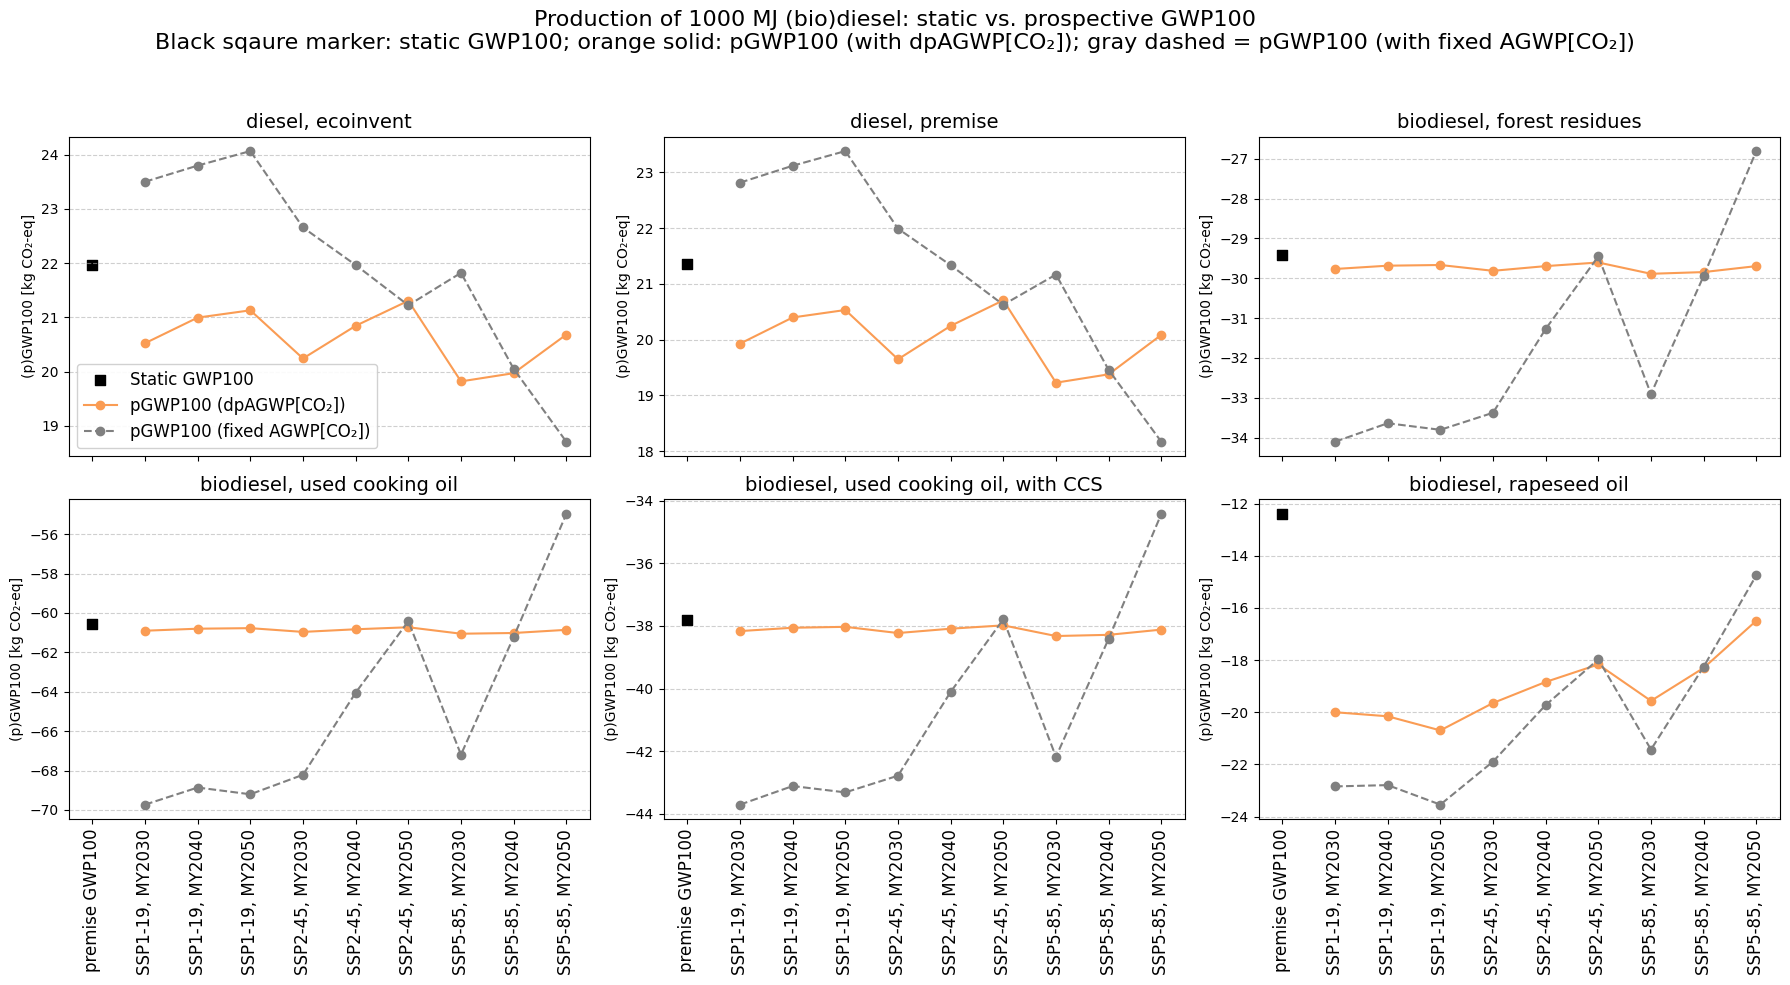

In [4]:
target_columns = [
    'diesel, ecoinvent',
    'diesel, premise',
    'biodiesel, forest residues',
    'biodiesel, used cooking oil',
    'biodiesel, used cooking oil, with CCS',
    'biodiesel, rapeseed oil'
]

# Identify static, dynamic, and fixed methods
static_label = 'premise GWP100'
dynamic_rows = [idx for idx in raw.index if 'dpAGWP[CO2]' in idx and 'fixed' not in idx]
fixed_rows   = [idx for idx in raw.index if 'fixed AGWP' in idx]

# Build x-axis labels
labels = [static_label] + dynamic_rows
labels_clean = [static_label] + [lbl.split('], ')[1] for lbl in dynamic_rows]
x = np.arange(len(labels))  # 0…9

fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axs = axs.flatten()

for ax, col in zip(axs, target_columns):
    # static point
    y_static = raw.at[static_label, col]
    ax.scatter(x[0], y_static,  marker='s',  color='black', s=60, label='Static GWP100')
    
    # dynamic series (orange solid), only x=1..9
    dyn_vals = [raw.at[r, col] for r in dynamic_rows]
    ax.plot(x[1:], dyn_vals, '-o', color='#fa9c54', label='pGWP100 (dpAGWP[CO₂])')
    
    # fixed series (gray dashed), only x=1..9
    fix_vals = [raw.at[r, col] for r in fixed_rows]
    ax.plot(x[1:], fix_vals, '--o', color='gray', label='pGWP100 (fixed AGWP[CO₂])')
    
    # formatting
    ax.set_title(col, fontsize=14)
    ax.set_ylabel("(p)GWP100 [kg CO₂-eq]")
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', rotation=90)
    
# shared x-axis labels on bottom row
for ax in axs[-3:]:
    ax.set_xticks(x)
    ax.set_xticklabels(labels_clean, fontsize=12)

# single legend
axs[0].legend(loc='lower left', framealpha=0.9, fontsize=12)

fig.suptitle(
    "Production of 1000 MJ (bio)diesel: static vs. prospective GWP100\n"
    "Black sqaure marker: static GWP100; orange solid: pGWP100 (with dpAGWP[CO₂]); gray dashed = pGWP100 (with fixed AGWP[CO₂])",
    fontsize=16
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("fig_output/two_sets_pgWPvsGWP_6diesel_lineplot1.png")
plt.show()

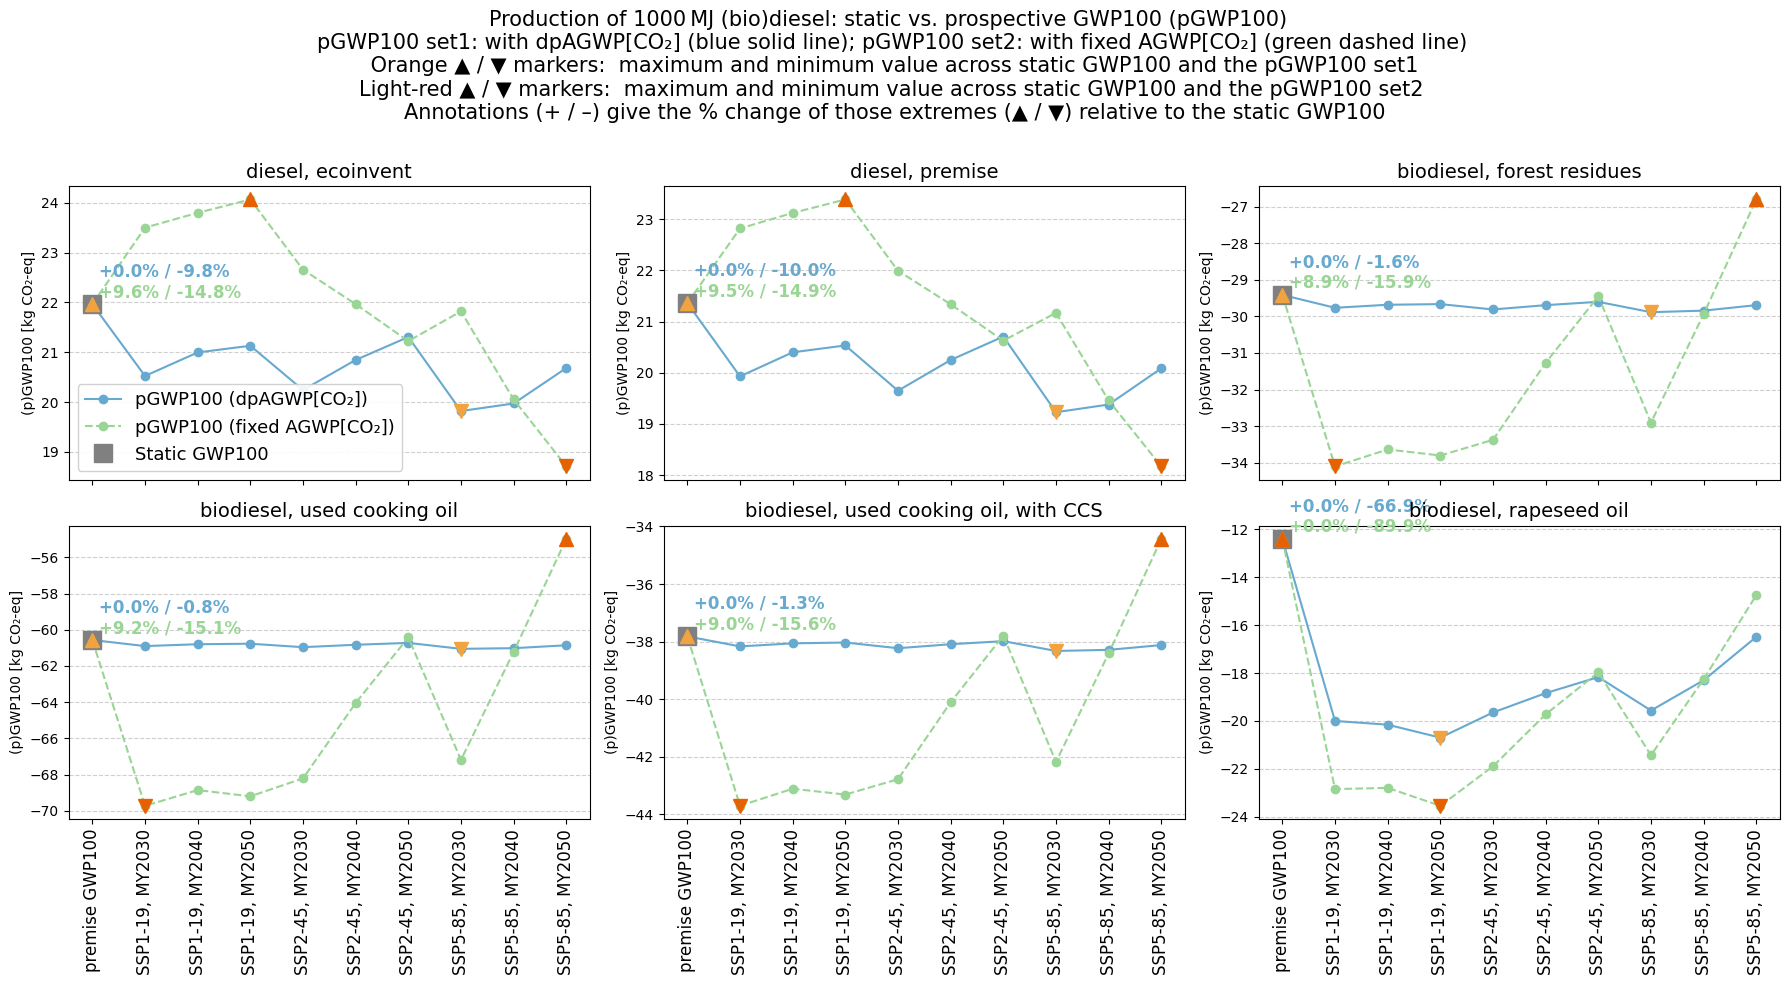

In [5]:
# target pathways
target_columns = [
    'diesel, ecoinvent',
    'diesel, premise',
    'biodiesel, forest residues',
    'biodiesel, used cooking oil',
    'biodiesel, used cooking oil, with CCS',
    'biodiesel, rapeseed oil'
]

#blue: #a6c2e0 
#green: #c5e0b4
#orange dots: #fa9c54 

# static, dynamic, and fixed rows
static_label = 'premise GWP100'
dynamic_rows = [idx for idx in raw.index if ('dpAGWP[CO2]' in idx and 'fixed' not in idx)]
fixed_rows   = [idx for idx in raw.index if 'fixed AGWP' in idx]

# x-axis labels
labels = [static_label] + dynamic_rows
labels_clean = [static_label] + [lbl.split('], ')[1] for lbl in dynamic_rows]
x = np.arange(len(labels))

fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axs = axs.flatten()

for ax, col in zip(axs, target_columns):
    # static baseline
    y_static = raw.at[static_label, col]
    
    # dp series (solid)
    y_dyn = [y_static] + [raw.at[r, col] for r in dynamic_rows]
    ax.plot(x, y_dyn, '-o', color='#67a9cf', label='pGWP100 (dpAGWP[CO₂])') 
    
    # fixed series (dashed)
    y_fix = [y_static] + [raw.at[r, col] for r in fixed_rows]
    ax.plot(x, y_fix, '--o', color='#99d594', label='pGWP100 (fixed AGWP[CO₂])')
    
    # static marker
    ax.plot(0, y_static, marker='s', color='gray', markersize=13, linestyle='None', label='Static GWP100')
    
    # dpAGWP[CO2] extremes
    dyn_arr = np.array(y_dyn, dtype=float)
    idx_dyn_min = np.nanargmin(dyn_arr)
    idx_dyn_max = np.nanargmax(dyn_arr)
    ax.plot(x[idx_dyn_max], dyn_arr[idx_dyn_max], '^', color='#f1a340', markersize=10)
    ax.plot(x[idx_dyn_min], dyn_arr[idx_dyn_min], 'v', color='#f1a340', markersize=10)
    
    # fixed CO2 extremes
    fix_arr = np.array(y_fix, dtype=float)
    idx_fix_min = np.nanargmin(fix_arr)
    idx_fix_max = np.nanargmax(fix_arr)
    ax.plot(x[idx_fix_max], fix_arr[idx_fix_max], '^', color='#e66101', markersize=10)  # light-red
    ax.plot(x[idx_fix_min], fix_arr[idx_fix_min], 'v', color='#e66101', markersize=10)
    
    # % change from static for dp
    pct_dyn_max = 100 * (dyn_arr[idx_dyn_max] - y_static) / abs(y_static)
    pct_dyn_min = 100 * (dyn_arr[idx_dyn_min] - y_static) / abs(y_static)
    
    # % change from static for fixed
    pct_fix_max = 100 * (fix_arr[idx_fix_max] - y_static) / abs(y_static)
    pct_fix_min = 100 * (fix_arr[idx_fix_min] - y_static) / abs(y_static)
    
    ax.annotate(f"+{pct_dyn_max:.1f}% / {pct_dyn_min:.1f}%", 
                xy=(0, y_static ), xytext=(5, 20),
                textcoords='offset points', color='#67a9cf', fontweight='bold',fontsize=12)
    ax.annotate(f"+{pct_fix_max:.1f}% / {pct_fix_min:.1f}%", 
                xy=(0, y_static ), xytext=(5, 5),
                textcoords='offset points', color='#99d594', fontweight='bold',fontsize=12)
    
    ax.set_title(col, fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_clean, rotation=90, fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_ylabel("(p)GWP100 [kg CO₂‑eq]")


axs[0].legend(loc='lower left', framealpha=0.9, fontsize=13)
fig.suptitle(
    "Production of 1000 MJ (bio)diesel: static vs. prospective GWP100 (pGWP100)  \n"
    "pGWP100 set1: with dpAGWP[CO₂] (blue solid line); pGWP100 set2: with fixed AGWP[CO₂] (green dashed line) \n "
    #"Triangle markers ▲/▼ show the overall maximum and minimum across static and the two pGWP100 sets\n"
    "Orange ▲ / ▼ markers:  maximum and minimum value across static GWP100 and the pGWP100 set1 \n"
    "Light-red ▲ / ▼ markers:  maximum and minimum value across static GWP100 and the pGWP100 set2 \n"
    "Annotations (+ / –) give the % change of those extremes (▲ / ▼) relative to the static GWP100",
    fontsize=15
)

plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig("fig_output/two_sets_pgWPvsGWP_6diesel_lineplot2_wh_text.png")
plt.show()

### lollipop with static GWP100 as baseline 

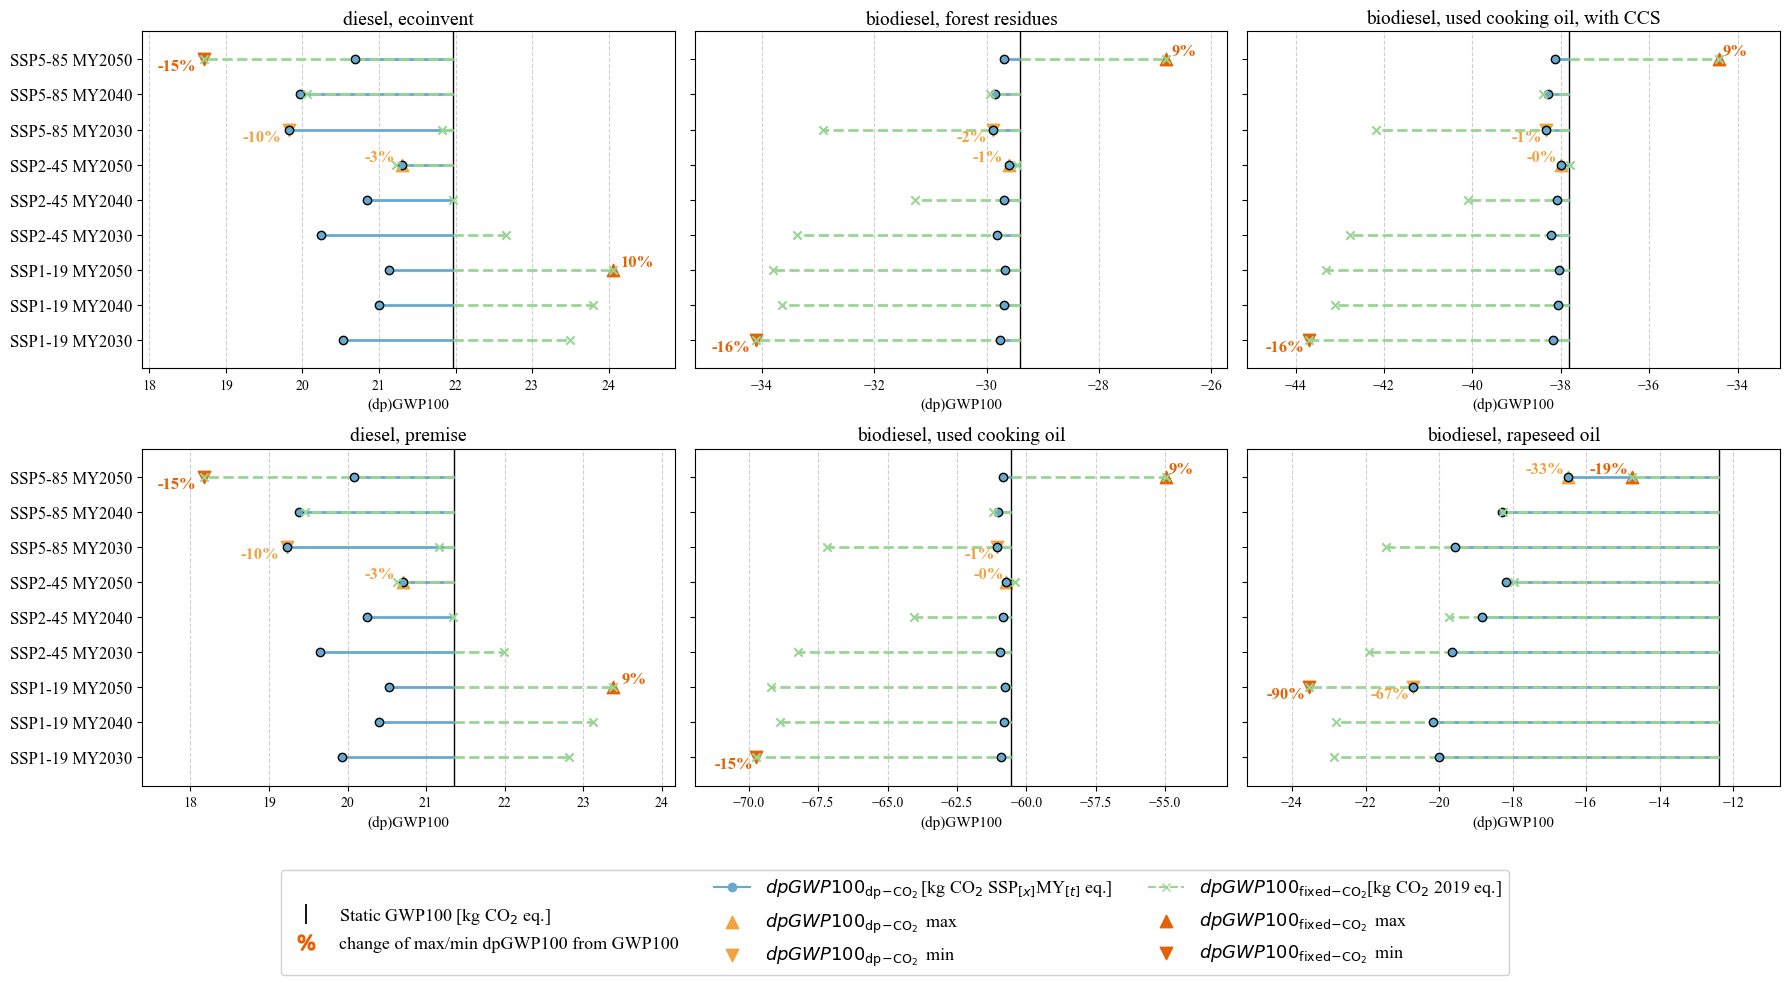

In [6]:
from matplotlib.lines import Line2D
import matplotlib.lines as mlines


BLUE   = '#67a9cf'    # dynamic line & markers 
GREEN  = '#99d594'    # fixed line & markers
ORANGE = "#f1a340"    # dp extremes ▲/▼
DRED   = "#e66101"    # fixed extremes ▲/▼
BLACK  = "black"      # static baseline

# 3. static label and method rows
static_label  = "premise GWP100"
dynamic_rows  = [r for r in raw.index if "dpAGWP[CO2]" in r and "fixed" not in r]
fixed_rows    = [r for r in raw.index if "fixed AGWP" in r]

# 4. scenario–year labels (from dynamic_rows)
labels_clean = []
for r in dynamic_rows:
    parts = r.split(", ")
    lab = f"{parts[1]} {parts[2]}" if len(parts)>=3 else parts[1]
    labels_clean.append(lab)

# 5. Y positions
y = np.arange(len(labels_clean))

# 6. pathways to plot
target_columns = [
    'diesel, ecoinvent',
    'diesel, premise',
    'biodiesel, forest residues',
    'biodiesel, used cooking oil',
    'biodiesel, used cooking oil, with CCS',
    'biodiesel, rapeseed oil'
]

# 7. 2×3 subplots, fill column-wise
fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharey=True)

for idx, pathway in enumerate(target_columns):
    row    = idx % 2
    colpos = idx // 2
    ax = axs[row, colpos]
    
    # baseline
    y_static = raw.at[static_label, pathway]
    ax.axvline(y_static, color=BLACK, linewidth=1)
    
    # dp series
    dyn_vals = [raw.at[r, pathway] for r in dynamic_rows]
    ax.hlines(y, y_static, dyn_vals, color=BLUE, linewidth=2)
    h_dyn = ax.scatter(dyn_vals, y, color=BLUE, edgecolor=BLACK, zorder=3)
    
    # fixed series
    fix_vals = [raw.at[r, pathway] for r in fixed_rows]
    ax.hlines(y, y_static, fix_vals, color=GREEN, linewidth=2, linestyle="--")
    h_fix = ax.scatter(fix_vals, y, color=GREEN, zorder=3, marker='x') #edgecolor=BLACK, 
    
    # dp extremes
    dyn_arr     = np.array(dyn_vals)
    i_max, i_min = dyn_arr.argmax(), dyn_arr.argmin()
    h_dyn_max = ax.scatter(dyn_arr[i_max], y[i_max], marker="^", color=ORANGE, s=80)
    h_dyn_min = ax.scatter(dyn_arr[i_min], y[i_min], marker="v", color=ORANGE, s=80)
    
    # fixed extremes
    fix_arr     = np.array(fix_vals)
    j_max, j_min = fix_arr.argmax(), fix_arr.argmin()
    h_fix_max = ax.scatter(fix_arr[j_max], y[j_max], marker="^", color=DRED, s=80)
    h_fix_min = ax.scatter(fix_arr[j_min], y[j_min], marker="v", color=DRED, s=80)
    
    #  % changes
    pct = lambda v: 100 * (v - y_static) / abs(y_static)

    ax.margins(x=0.15, y = 0.1) # more margin 


    # how far (in GWP units) to shift each label
    dx = 0.1 
    # --- dp extremes (orange ▲) --- 
    for idx in (i_max, i_min):
        v = dyn_arr[idx]
        p = pct(v)                    # signed percent change
        # decide shift & alignment based on which side of static baseline we are
        if v > y_static:
            xoff, ha = dx, "left"
        else:
            xoff, ha = -dx, "right"
        va = "bottom" if idx == i_max else "top"
        ax.text(
            v + xoff, y[idx], f"{p:.0f}%",
            color=ORANGE, va=va, ha=ha,
            fontsize=12, fontweight="bold"
        )
    
    # --- fixed extremes (red ▲) --- 
    for idx in (j_max, j_min):
        v = fix_arr[idx]
        p = pct(v)
        # again decide shift/alignment so red never overlaps its ▲
        if v > y_static:
            xoff, ha = dx, "left"
        else:
            xoff, ha = -dx, "right"
        va = "bottom" if idx == j_max else "top"
        ax.text(
            v + xoff, y[idx], f"{p:.0f}%",
            color=DRED, va=va, ha=ha,
            fontsize=12, fontweight="bold"
        )


    ax.set_yticks(y)
    ax.set_yticklabels(labels_clean, fontsize=12)
    #if row == 1: # Anne wants all xlabels
    ax.set_xlabel("(dp)GWP100", fontsize = 11)
    #ax.set_xlabel("GWP100 [kg CO₂-eq] \n"
    #              "pGWP100dynSSP [kg CO₂ SSP[x]MY[t] eq.] \n"
    #              "pGWP100fixed-CO₂ [kg CO2 2019 eq.]", fontsize=12)
    ax.set_title(pathway, fontsize=14)
    ax.grid(axis="x", linestyle="--", alpha=0.6)

# 8. custom legend # new “combined” handles, label seperately 
h_static = Line2D(
    [0], [0],
    color=BLACK,
    marker='|',          # vertical bar
    linestyle='None',
    markersize=15,       # adjust height
    markeredgewidth=1.3,   # line thickness
)
# mlt legends always draw lines horizontally, 
#h_static = Line2D([0], [0],
#                  color='black', linestyle='-',
#                  #label='Static GWP100 [kg CO₂-eq]'
#                 )

h_dyn    = Line2D([0], [0],
                  color=BLUE, marker='o',
                  linestyle='-',
                  #label=r"$pGWP_{100,\mathrm{dynSSP}}$ [kg CO$_2$, SSP[x]MY[t] eq.]"
                 )

h_fix    = Line2D([0], [0],
                  color=GREEN, marker='x',
                  linestyle='--',
                  #label=r"$pGWP_{100,\mathrm{fixed-CO_2}}$ [kg CO$_2$ 2019 eq.]"
                 )

# blank spacer
h_blank = Line2D([], [], linestyle="None", label="")
# orange *% 
h_blank_text  = Line2D(
    [], [], 
    marker=r'$\%$',             # %marker
    linestyle='None',        # no connecting line
    markersize=12,           # size up 
    markerfacecolor=ORANGE,  # fill color
    markeredgecolor=DRED,    # edge color
)


# assemble in desired order
handles = [
    h_blank,
    h_static,
    h_blank_text,
    h_dyn,
    h_dyn_max,
    h_dyn_min,
    h_fix,
    h_fix_max,
    h_fix_min
]
labels = [
     "",    # blank slot 
    "Static GWP100 [kg CO$_2$ eq.] ",
    r"change of max/min dpGWP100 from GWP100",                              
    
    r"$dpGWP100_{\mathrm{dp\!-\!CO_2}}\, $[kg CO$_2$ SSP$_{[x]}$MY$_{[t]}$ eq.]",
    r"$dpGWP100_{\mathrm{dp\!-\!CO_2}}\,$ max",
    r"$dpGWP100_{\mathrm{dp\!-\!CO_2}}\,$ min",
    
    r"$dpGWP100_{\mathrm{fixed\!-\!CO_2}} $[kg CO$_2$ 2019 eq.]",
    r"$dpGWP100_{\mathrm{fixed\!-\!CO_2}}\,$ max",
    r"$dpGWP100_{\mathrm{fixed\!-\!CO_2}}\,$ min",

]

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    framealpha=0.9,
    fontsize=13,
)

# Super‐title
#fig.suptitle(
    #"Production of 1000 MJ (bio)diesel: static vs. two sets of prospective GWP100\n"
    #"Blue solid = pGWP100 (w/h dpAGWP[CO₂])   |   Green dashed =  pGWP100 (w/h fixed AGWP[CO₂]) \n"
    #"Orange ▲/▼ = pGWP100 (w/h dpAGWP[CO₂]) extremes   |  Light-red ▲/▼ = pGWP100 (w/h fixed AGWP[CO₂]) extremes ",
#    fontsize=16
#)

plt.tight_layout(rect=[0, 0.12, 1, 0.97])
plt.savefig("fig_output/two_sets_pgWPvsGWP_6diesel_lollipop.png", bbox_inches='tight', pad_inches=0.1)
plt.show()
